In [1]:
# !python -m spacy download en_core_web_trf

# !pip install spacy-transformers
# !pip install spacy[transformers]
# !pip install tqdm -q

In [ ]:
from google.colab import drive
import spacy
from spacy.pipeline import EntityRuler
import pandas as pd


import pickle
import time
import os
from tqdm import tqdm
import torch
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import json


In [ ]:

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
df_filtered = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/news_cleaned_filtered_v2.parquet')

# Entity Extraction Pipeline - Quick Start Guide

##  Purpose
Extract and analyze organizations, technologies, and industries mentioned in AI-related news articles to identify companies most affected by AI.



- **Caching**: Results saved to disk - rerun instantly without reprocessing
- **Progress tracking**: See extraction progress with tqdm
- **Enhanced filtering**: Comprehensive blocklist removes wire services (Gray Media, PRNewswire, etc.)
- **Performance metrics**: Track processing speed and statistics



In [ ]:
expanded_patterns = [
    # ==========================================
    # 1. TECHNOLOGIES (TECH)
    # ==========================================
    # Core AI & Generative AI
    {"label": "TECH", "pattern": [{"LOWER": "artificial"}, {"LOWER": "intelligence"}]},
    {"label": "TECH", "pattern": [{"LOWER": "generative"}, {"LOWER": "ai"}]},
    {"label": "TECH", "pattern": [{"LOWER": "genai"}]},
    {"label": "TECH", "pattern": [{"LOWER": "large"}, {"LOWER": "language"}, {"LOWER": "model"}]},
    {"label": "TECH", "pattern": [{"LOWER": "large"}, {"LOWER": "language"}, {"LOWER": "models"}]},
    {"label": "TECH", "pattern": [{"LOWER": "llm"}]},
    {"label": "TECH", "pattern": [{"LOWER": "llms"}]},
    {"label": "TECH", "pattern": [{"LOWER": "chatgpt"}]},
    {"label": "TECH", "pattern": [{"LOWER": "gpt-4"}]},
    {"label": "TECH", "pattern": [{"LOWER": "copilot"}]},
    {"label": "TECH", "pattern": [{"LOWER": "foundation"}, {"LOWER": "models"}]},

    # Machine Learning & Data Science
    {"label": "TECH", "pattern": [{"LOWER": "machine"}, {"LOWER": "learning"}]},
    {"label": "TECH", "pattern": [{"LOWER": "deep"}, {"LOWER": "learning"}]},
    {"label": "TECH", "pattern": [{"LOWER": "neural"}, {"LOWER": "networks"}]},
    {"label": "TECH", "pattern": [{"LOWER": "predictive"}, {"LOWER": "analytics"}]},
    {"label": "TECH", "pattern": [{"LOWER": "data"}, {"LOWER": "science"}]},

    # NLP & Vision (Abstract Thought)
    {"label": "TECH", "pattern": [{"LOWER": "natural"}, {"LOWER": "language"}, {"LOWER": "processing"}]},
    {"label": "TECH", "pattern": [{"LOWER": "nlp"}]},
    {"label": "TECH", "pattern": [{"LOWER": "computer"}, {"LOWER": "vision"}]},
    {"label": "TECH", "pattern": [{"LOWER": "image"}, {"LOWER": "recognition"}]},

    # Robotics & Physical (Sensorimotor / Moravec's Paradox)
    {"label": "TECH", "pattern": [{"LOWER": "robotics"}]},
    {"label": "TECH", "pattern": [{"LOWER": "autonomous"}, {"LOWER": "vehicles"}]},
    {"label": "TECH", "pattern": [{"LOWER": "robotic"}, {"LOWER": "process"}, {"LOWER": "automation"}]},
    {"label": "TECH", "pattern": [{"LOWER": "rpa"}]},
    {"label": "TECH", "pattern": [{"LOWER": "drones"}]},

    # ==========================================
    # 2. INDUSTRIES & SECTORS (INDUSTRY)
    # ==========================================
    # High-Impact (Knowledge Work from Goldman Sachs)
    {"label": "INDUSTRY", "pattern": [{"LOWER": "legal"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "law"}, {"LOWER": "firms"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "architecture"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "social"}, {"LOWER": "sciences"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "finance"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "banking"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "software"}, {"LOWER": "engineering"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "customer"}, {"LOWER": "service"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "healthcare"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "medicine"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "education"}]},

    # Low-Impact (Sensorimotor / Physical tasks from Goldman Sachs)
    {"label": "INDUSTRY", "pattern": [{"LOWER": "construction"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "building"}, {"LOWER": "maintenance"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "installation"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "manufacturing"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "agriculture"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "transportation"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "logistics"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "supply"}, {"LOWER": "chain"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "retail"}]},

    # --- MORAVEC'S PARADOX CONCEPTS (Direct nod to the prompt) ---
    {"label": "TECH", "pattern": [{"LOWER": "sensorimotor"}, {"LOWER": "skills"}]},
    {"label": "TECH", "pattern": [{"LOWER": "sensorimotor"}]},
    {"label": "TECH", "pattern": [{"LOWER": "abstract"}, {"LOWER": "thought"}]},
    {"label": "TECH", "pattern": [{"LOWER": "reasoning"}]},

    # --- MODERN AI & APPLIED TECH ---
    {"label": "TECH", "pattern": [{"LOWER": "predictive"}, {"LOWER": "analytics"}]},
    {"label": "TECH", "pattern": [{"LOWER": "robotics"}]},
    {"label": "TECH", "pattern": [{"LOWER": "robotic"}, {"LOWER": "process"}, {"LOWER": "automation"}]},
    {"label": "TECH", "pattern": [{"LOWER": "rpa"}]},
    {"label": "TECH", "pattern": [{"LOWER": "computer"}, {"LOWER": "vision"}]},
    {"label": "TECH", "pattern": [{"LOWER": "deep"}, {"LOWER": "learning"}]},
    {"label": "TECH", "pattern": [{"LOWER": "natural"}, {"LOWER": "language"}, {"LOWER": "processing"}]},

    # --- RUBRIC-SPECIFIC INDUSTRIES (High & Low Impact Targets) ---
    {"label": "INDUSTRY", "pattern": [{"LOWER": "office"}, {"LOWER": "tasks"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "legal"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "architecture"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "social"}, {"LOWER": "sciences"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "construction"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "installation"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "building"}, {"LOWER": "maintenance"}]},


    # ==========================================
    # 3. IMPACT MECHANISMS (IMPACT)
    # ==========================================
    # Directly answers: "Determine how those industries... will be impacted"
    {"label": "IMPACT", "pattern": [{"LOWER": "automation"}]},
    {"label": "IMPACT", "pattern": [{"LOWER": "automated"}]},
    {"label": "IMPACT", "pattern": [{"LOWER": "augmentation"}]},
    {"label": "IMPACT", "pattern": [{"LOWER": "augmented"}]},
    {"label": "IMPACT", "pattern": [{"LOWER": "workflow"}, {"LOWER": "redesign"}]},
    {"label": "IMPACT", "pattern": [{"LOWER": "cost"}, {"LOWER": "savings"}]},
    {"label": "IMPACT", "pattern": [{"LOWER": "job"}, {"LOWER": "displacement"}]},
    {"label": "IMPACT", "pattern": [{"LOWER": "job"}, {"LOWER": "creation"}]},
    {"label": "IMPACT", "pattern": [{"LOWER": "efficiency"}]},
    {"label": "IMPACT", "pattern": [{"LOWER": "productivity"}]},
    {"label": "IMPACT", "pattern": [{"LOWER": "upskilling"}]},
    {"label": "IMPACT", "pattern": [{"LOWER": "reskilling"}]},
    {"label": "IMPACT", "pattern": [{"LOWER": "process"}, {"LOWER": "optimization"}]},
    {"label": "IMPACT", "pattern": [{"LOWER": "decision"}, {"LOWER": "support"}]}

]


In [ ]:
#  Load the spaCy model

MODEL_NAME = "en_core_web_trf"

#  Enable GPU for transformer models
if MODEL_NAME == "en_core_web_trf":
    print("Checking GPU availability...")
    try:
        if torch.cuda.is_available():
            print(f"GPU detected: {torch.cuda.get_device_name(0)}")
            print(f"  GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

            # Use GPU
            spacy.require_gpu()
            print("GPU enabled for spaCy")
        else:
            print(" No GPU detected - transformer model will run on CPU (VERY SLOW!)")
            print("   Switch to T4 GPU runtime: Runtime → Change runtime type → T4 GPU")
    except Exception as e:
        print(f" Error enabling GPU: {e}")

print(f"\nLoading spaCy model: {MODEL_NAME}...")
nlp = spacy.load(MODEL_NAME)
print(f"Loaded {MODEL_NAME}")
print(f"  Pipeline components: {nlp.pipe_names}")

# Verify GPU is being used
if MODEL_NAME == "en_core_web_trf":
    try:
        # Check if model is on GPU
        transformer = nlp.get_pipe("transformer")
        device = next(transformer.model.parameters()).device
        if device.type == "cuda":
            print(f"  Model is on GPU: {device}")
            print(f"  Expected speed: ~30-50 articles/sec")
        else:
            print(f"   Model is on CPU: {device}")
            print(f"  Expected speed: ~1-3 articles/sec (TOO SLOW!)")
            print(f"  ACTION REQUIRED: Restart runtime with GPU enabled")
    except:
        pass
elif MODEL_NAME == "en_core_web_lg":
    print(f"  Expected speed: ~30-60 articles/sec on CPU")
else:
    print(f"  Expected speed: ~50-100 articles/sec on CPU")

# Create and add the custom EntityRuler BEFORE the standard 'ner' component
# This ensures our custom rules take priority over the model's default guesses.
ruler = nlp.add_pipe("entity_ruler", before="ner")

# Define custom patterns (list expanded using expanded_patterns)
patterns = [
    # --- Technologies ---
    {"label": "TECH", "pattern": [{"LOWER": "generative"}, {"LOWER": "ai"}]},
    {"label": "TECH", "pattern": [{"LOWER": "chatgpt"}]},
    {"label": "TECH", "pattern": [{"LOWER": "large"}, {"LOWER": "language"}, {"LOWER": "model"}]},
    {"label": "TECH", "pattern": [{"LOWER": "llm"}]},
    {"label": "TECH", "pattern": [{"LOWER": "machine"}, {"LOWER": "learning"}]},
    {"label": "TECH", "pattern": [{"LOWER": "computer"}, {"LOWER": "vision"}]},

    # --- Industries (Align these with the Goldman Sachs report!) ---
    {"label": "INDUSTRY", "pattern": [{"LOWER": "healthcare"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "finance"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "legal"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "architecture"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "construction"}]},
    {"label": "INDUSTRY", "pattern": [{"LOWER": "retail"}]}
]

ruler.add_patterns(patterns)
ruler.add_patterns(expanded_patterns)

print(f"Added {len(patterns) + len(expanded_patterns)} custom entity patterns")

Checking GPU availability...
GPU detected: Tesla T4
  GPU memory: 15.6 GB
GPU enabled for spaCy

Loading spaCy model: en_core_web_trf...
Loaded en_core_web_trf
  Pipeline components: ['transformer', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
Added 89 custom entity patterns


In [ ]:
# Verify GPU status
print("=" * 60)
print("GPU STATUS CHECK")
print("=" * 60)

# Check PyTorch CUDA
print(f"\n1. PyTorch CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU name: {torch.cuda.get_device_name(0)}")
    print(f"   GPU memory allocated: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
    print(f"   GPU memory reserved: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")
else:
    print("    No CUDA GPU detected")

# Check spaCy model location
print(f"\n2. spaCy model: {MODEL_NAME}")
try:
    if MODEL_NAME == "en_core_web_trf":
        # Check GPU usage by memory allocation
        if torch.cuda.is_available():
            # Force a small inference to allocate memory
            _ = nlp("test")
            gpu_memory = torch.cuda.memory_allocated(0) / 1e9

            if gpu_memory > 0.1:
                print(f"   Model is on GPU (using {gpu_memory:.2f} GB)")
            else:
                print(f"    Model appears to be on CPU")
                print(f"   GPU memory allocated: {gpu_memory:.2f} GB")
                print(f"   ACTION: Rerun model loading cell to enable GPU")
        else:
            print(f"    CUDA not available - model is on CPU")
    else:
        # Check if GPU is actually being used
        gpu_memory = torch.cuda.memory_allocated(0) / 1e9

except:
        print(f"   Unknown - rerun model loading cell")


GPU STATUS CHECK

1. PyTorch CUDA available: True
   GPU name: Tesla T4
   GPU memory allocated: 0.50 GB
   GPU memory reserved: 1.07 GB

2. spaCy model: en_core_web_trf


/usr/local/lib/python3.12/dist-packages/thinc/util.py:395: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  dlpack_tensor = xp_tensor.toDlpack()  # type: ignore


   Model is on GPU (using 0.51 GB)


In [ ]:
# OPTIMIZED Extraction Function with Caching, Progress Tracking & CHECKPOINTING
# !pip install tqdm -q


def extract_entities_optimized(text_series, batch_size=1000, cache_file='entity_cache.pkl',
                                use_cache=True, checkpoint_dir=None, checkpoint_interval=5):
    # Try to load final cached results first
    if use_cache:
        try:
            with open(cache_file, 'rb') as f:
                cached = pickle.load(f)
                print(f"Loaded {len(cached['organizations'])} cached results from {cache_file}")
                if len(cached['organizations']) == len(text_series):
                    print("Cache matches input size - using cached results")
                    return cached['organizations'], cached['technologies'], cached['industries']
                else:
                    print(f"Cache size mismatch ({len(cached['organizations'])} vs {len(text_series)})")
                    print("  Processing from scratch...")
        except FileNotFoundError:
            print(f"No cache found at {cache_file}, processing from scratch...")
        except Exception as e:
            print(f"Error loading cache: {e}")
            print("  Processing from scratch...")

    # Initialize or load checkpoint
    organizations = []
    technologies = []
    industries = []
    impact_mechanisms = []
    start_batch = 0

    checkpoint_file = None
    if checkpoint_dir:
        os.makedirs(checkpoint_dir, exist_ok=True)
        checkpoint_file = os.path.join(checkpoint_dir, f'checkpoint_{cache_file}')

        # Try to load existing checkpoint
        try:
            with open(checkpoint_file, 'rb') as f:
                checkpoint = pickle.load(f)
                organizations = checkpoint['organizations']
                technologies = checkpoint['technologies']
                industries = checkpoint['industries']
                impact_mechanisms = checkpoint['impact_mechanisms']
                start_batch = checkpoint['last_batch'] + 1

                print(f"CHECKPOINT FOUND: Resuming from batch {start_batch}")
                print(f"  Already processed: {len(organizations):,} documents")
                print(f"  Remaining: {len(text_series) - len(organizations):,} documents")
        except FileNotFoundError:
            print(f"No checkpoint found, starting fresh")
            print(f"  Checkpoints will be saved to: {checkpoint_dir}")
        except Exception as e:
            print(f"Error loading checkpoint: {e}")
            print("  Starting from beginning")

    # Start timing
    start_time = time.time()

    # Process in batches with progress bar
    total_docs = len(text_series)
    total_batches = (total_docs + batch_size - 1) // batch_size

    print(f"\nProcessing {total_docs:,} documents in {total_batches} batches of {batch_size}...")
    if checkpoint_dir:
        print(f"Checkpoint will be saved every {checkpoint_interval} batches to Google Drive")

    # Calculate starting index based on checkpoint
    start_idx = len(organizations)

    for batch_num in tqdm(range(start_batch, total_batches),
                          desc="Extracting entities",
                          unit="batch",
                          initial=start_batch,
                          total=total_batches):

        # Get batch slice
        batch_start = batch_num * batch_size
        batch_end = min(batch_start + batch_size, total_docs)
        batch = text_series.iloc[batch_start:batch_end]

        # Track batch timing
        batch_start_time = time.time()

        # Only enable necessary components 
        for doc in nlp.pipe(batch, batch_size=batch_size,
                           disable=["tagger", "parser", "attribute_ruler", "lemmatizer"],
                           n_process=1):  # Single process to avoid memory issues

            orgs = list(set([ent.text for ent in doc.ents if ent.label_ == "ORG"]))
            techs = list(set([ent.text for ent in doc.ents if ent.label_ == "TECH"]))
            inds = list(set([ent.text for ent in doc.ents if ent.label_ == "INDUSTRY"]))
            impacts = list(set([ent.text for ent in doc.ents if ent.label_ == "IMPACT"]))


            organizations.append(orgs)
            technologies.append(techs)
            industries.append(inds)
            impact_mechanisms.append(impacts)

        # Calculate batch speed
        batch_elapsed = time.time() - batch_start_time
        batch_speed = len(batch) / batch_elapsed if batch_elapsed > 0 else 0

        # Save checkpoint periodically
        if checkpoint_dir and (batch_num + 1) % checkpoint_interval == 0:
            try:
                with open(checkpoint_file, 'wb') as f:
                    pickle.dump({
                        'organizations': organizations,
                        'technologies': technologies,
                        'industries': industries,
                        'impact_mechanisms': impact_mechanisms,
                        'last_batch': batch_num,
                        'timestamp': time.time(),
                        'total_docs': total_docs
                    }, f)
                print(f"Checkpoint saved (batch {batch_num + 1}/{total_batches}, {len(organizations):,} docs, {batch_speed:.1f} docs/sec)")
            except Exception as e:
                print(f"Error saving checkpoint: {e}")

    # Calculate final performance metrics
    elapsed = time.time() - start_time
    docs_processed = len(organizations) - start_idx
    docs_per_sec = docs_processed / elapsed if elapsed > 0 else 0

    print(f"\nCompleted in {elapsed:.1f} seconds")
    print(f"  Speed: {docs_per_sec:.1f} documents/second")
    print(f"  Average: {(elapsed/docs_processed)*1000:.2f} ms/document")

    # Save final cache
    if use_cache:
        try:
            with open(cache_file, 'wb') as f:
                pickle.dump({
                    'organizations': organizations,
                    'technologies': technologies,
                    'industries': industries,
                    'impact_mechanisms': impact_mechanisms,
                    'last_batch': batch_num,
                    'timestamp': time.time(),
                    'doc_count': total_docs
                }, f)
            print(f"Results cached to {cache_file}")
        except Exception as e:
            print(f"Error saving cache: {e}")
    return organizations, technologies, industries, impact_mechanisms

### Run on a sample to test

In [ ]:
# 6. Sampling Utility for Faster Testing
def create_stratified_sample(df, text_col='cleaned_text_v2', sample_frac=0.1, random_state=42):
    # If dataframe has a date column, stratify by year
    if 'pub_date' in df.columns or 'date' in df.columns:
        date_col = 'pub_date' if 'pub_date' in df.columns else 'date'
        try:
            df['_temp_year'] = pd.to_datetime(df[date_col], errors='coerce').dt.year
            df_sample = df.groupby('_temp_year', group_keys=False).apply(
                lambda x: x.sample(frac=sample_frac, random_state=random_state) if len(x) > 0 else x
            )
            df_sample = df_sample.drop(columns=['_temp_year'])
            df = df.drop(columns=['_temp_year'])
            print(f"Created stratified sample by year")
        except Exception as e:
            print(f"Could not stratify by date: {e}")
            df_sample = df.sample(frac=sample_frac, random_state=random_state)
    else:
        df_sample = df.sample(frac=sample_frac, random_state=random_state)

    print(f"Sampled {len(df_sample):,} articles from {len(df):,} total ({sample_frac*100:.1f}%)")
    return df_sample

### Running on the entire dataset

In [ ]:
# Clear GPU memory before starting long extraction

print("Clearing GPU memory...")

# Clear Python garbage
gc.collect()

# Clear PyTorch CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    # Show memory status
    allocated = torch.cuda.memory_allocated(0) / 1e9
    reserved = torch.cuda.memory_reserved(0) / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    free = total - allocated

    print(f"GPU memory cleared")
    print(f"Total: {total:.2f} GB")
    print(f"Allocated: {allocated:.2f} GB")
    print(f"Reserved: {reserved:.2f} GB")
    print(f"Free: {free:.2f} GB")

    if allocated > 5:
        print(f"Warning: {allocated:.2f} GB still allocated")
        print(f"Consider restarting runtime if memory issues persist")
else:
    print("CUDA not available")

# Set PyTorch memory allocation strategy to reduce fragmentation
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
print("Set PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True")

Clearing GPU memory...
GPU memory cleared
Total: 15.64 GB
Allocated: 0.51 GB
Reserved: 0.56 GB
Free: 15.13 GB
Set PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True


In [ ]:
# Check checkpoint status without running extraction


# checkpoint_dir = '/content/drive/MyDrive/nlp_checkpoints/'
checkpoint_dir = '/content/drive/MyDrive/Colab Notebooks/nlp_checkpoints/' 

checkpoint_file = os.path.join(checkpoint_dir, 'checkpoint_entity_cache_full.pkl')

if os.path.exists(checkpoint_file):
    try:
        with open(checkpoint_file, 'rb') as f:
            checkpoint = pickle.load(f)

        total_docs = checkpoint['total_docs']
        processed = len(checkpoint['organizations'])
        last_batch = checkpoint['last_batch']
        remaining = total_docs - processed
        progress_pct = (processed / total_docs) * 100

        print("CHECKPOINT STATUS")
        print("=" * 60)
        print(f"  Total documents:     {total_docs:,}")
        print(f"  Processed:           {processed:,} ({progress_pct:.1f}%)")
        print(f"  Remaining:           {remaining:,}")
        print(f"  Last completed batch: {last_batch}")
        print(f"  Checkpoint saved:    {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(checkpoint['timestamp']))}")
        print("=" * 60)
        print("\nCan resume by running the extraction cell again")

    except Exception as e:
        print(f" Error reading checkpoint: {e}")
else:
    print("ℹ No checkpoint found")
    print(f"  Looking for: {checkpoint_file}")
    print("\n  Either:")
    print("  1. No extraction has started yet")
    print("  2. Extraction completed (checkpoint cleaned up)")
    print("  3. Checkpoint directory path is incorrect")

In [ ]:
# 8. Run extraction on the entire dataset with checkpointing

print(f"Extracting entities from FULL dataset ({len(df_filtered):,} articles)...")
print("With transformer model, this may take 60-90 minutes on T4 GPU.")
print("Results and checkpoints will be saved for resuming.\n")

#With Google Drive checkpointing
# Set checkpoint_dir to  Google Drive path
CHECKPOINT_DIR = '/content/drive/MyDrive/Colab Notebooks/nlp_checkpoints/'  # Change if needed

orgs, techs, inds, impacts = extract_entities_optimized(
    df_filtered['cleaned_text_v2'],
    batch_size=200,  # Larger batches for efficiency
    cache_file='entity_cache_full.pkl',
    checkpoint_dir=CHECKPOINT_DIR,  # Enable checkpointing
    checkpoint_interval=5  # Save every 5 batches (~5K docs)
)

# Add the extracted lists back into dataframe as new columns
df_filtered['organizations'] = orgs
df_filtered['technologies'] = techs
df_filtered['industries'] = inds
df_filtered['impacts'] = impacts

# Check the results!
print("\nFull dataset extraction complete!")
print(df_filtered[['organizations', 'technologies', 'industries', 'impacts']].head())

Extracting entities from FULL dataset (142,007 articles)...
With transformer model, this may take 60-90 minutes on T4 GPU.
Results and checkpoints will be saved for resuming.

No cache found at entity_cache_full.pkl, processing from scratch...
No checkpoint found, starting fresh
  Checkpoints will be saved to: /content/drive/MyDrive/Colab Notebooks/nlp_checkpoints/

Processing 142,007 documents in 711 batches of 200...
Checkpoint will be saved every 5 batches to Google Drive


Extracting entities:   0%|          | 0/711 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/thinc/util.py:395: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  dlpack_tensor = xp_tensor.toDlpack()  # type: ignore
Extracting entities:   0%|          | 1/711 [00:21<4:17:00, 21.72s/batch]/usr/local/lib/python3.12/dist-packages/thinc/util.py:395: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  dlpack_tensor = xp_tensor.toDlpack()  # type: ignore
Extracting entities:   0%|          | 2/711 [00:43<4:19:04, 21.92s/batch]/usr/local/lib/python3.12/dist-packages/thinc/util.py:395: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  dlpack_tensor = xp_tensor.toDlpack()  # type: ignore

Checkpoint saved (batch 5/711, 1,000 docs, 7.5 docs/sec)


/usr/local/lib/python3.12/dist-packages/thinc/util.py:395: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  dlpack_tensor = xp_tensor.toDlpack()  # type: ignore
Extracting entities:   1%|          | 6/711 [02:24<4:53:39, 24.99s/batch]/usr/local/lib/python3.12/dist-packages/thinc/util.py:395: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  dlpack_tensor = xp_tensor.toDlpack()  # type: ignore
Extracting entities:   1%|          | 7/711 [02:53<5:09:56, 26.41s/batch]/usr/local/lib/python3.12/dist-packages/thinc/util.py:395: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  dlpack_tensor = xp_tensor.toDlpack()  # type: ignore
Extracting entities:   1%|          | 8/711 [03:18<5:02:03, 25

Checkpoint saved (batch 10/711, 2,000 docs, 8.2 docs/sec)


...

Checkpoint saved (batch 705/711, 141,000 docs, 9.2 docs/sec)


/usr/local/lib/python3.12/dist-packages/thinc/util.py:395: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  dlpack_tensor = xp_tensor.toDlpack()  # type: ignore
Extracting entities:  99%|█████████▉| 706/711 [4:44:40<01:55, 23.09s/batch]/usr/local/lib/python3.12/dist-packages/thinc/util.py:395: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  dlpack_tensor = xp_tensor.toDlpack()  # type: ignore
Extracting entities:  99%|█████████▉| 707/711 [4:45:03<01:32, 23.12s/batch]/usr/local/lib/python3.12/dist-packages/thinc/util.py:395: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  dlpack_tensor = xp_tensor.toDlpack()  # type: ignore
Extracting entities: 100%|█████████▉| 708/711 [4:45:26<01:

Checkpoint saved (batch 710/711, 142,000 docs, 8.7 docs/sec)


/usr/local/lib/python3.12/dist-packages/thinc/util.py:395: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  dlpack_tensor = xp_tensor.toDlpack()  # type: ignore
Extracting entities: 100%|██████████| 711/711 [4:46:16<00:00, 24.16s/batch]



Completed in 17176.3 seconds
  Speed: 8.3 documents/second
  Average: 120.95 ms/document
Results cached to entity_cache_full.pkl

Full dataset extraction complete!
                                       organizations  \
0  [Bad Idea AI?Currently, Bad Idea AI?Bad Idea A...   
1  [Milwaukee Tool company, Amazon.com, Youtube, ...   
2  [Anthropic, 1minAI, Boing Boing Shop, Apple, t...   
3  [mensaxe navegaciónA, Baidu, Fundación AI de C...   
4  [GeForce, Windows, Hugging Face, Nvidia, OpenA...   

                               technologies        industries       impacts  
0                                        []                []            []  
1                                        []                []            []  
2                          [GPT-4, ChatGPT]                []            []  
3  [deep learning, artificial intelligence]  [transportation]            []  
4        [LLM, LLMs, large language models]                []  [efficiency]  


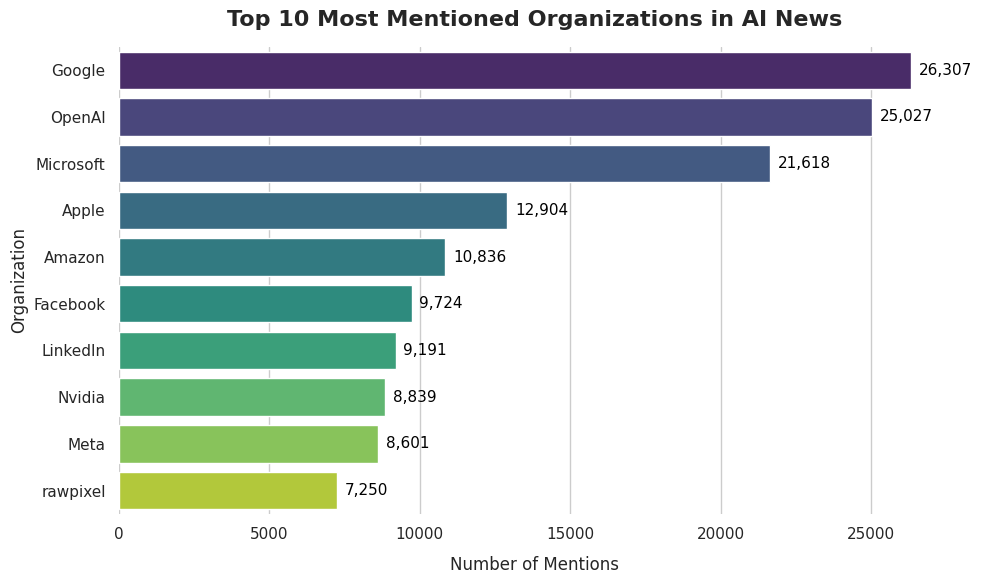

In [ ]:

# Explode the lists into individual rows
exploded_orgs = df_filtered['organizations'].explode()

# Drop missing values and convert to string
exploded_orgs = exploded_orgs.dropna().astype(str).str.strip()

# Filter out common false positives spaCy might catch as ORGs
false_positives = ['AI', 'ChatGPT', 'LLM', 'EU', 'US']
exploded_orgs = exploded_orgs[~exploded_orgs.isin(false_positives)]
# Filter out entities that are too short (likely noise)
exploded_orgs = exploded_orgs[exploded_orgs.str.len() > 1]

# Get the Top 10 counts
top_10_orgs = exploded_orgs.value_counts().head(10)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create a horizontal barplot 
ax = sns.barplot(
    x=top_10_orgs.values,
    y=top_10_orgs.index,
    hue= top_10_orgs.index,
    palette="viridis",
    orient='h'
)

# 5. Formatting
plt.title('Top 10 Most Mentioned Organizations in AI News', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Mentions', fontsize=12, labelpad=10)
plt.ylabel('Organization', fontsize=12)

# Add data labels to the end of each bar
for i, v in enumerate(top_10_orgs.values):
    ax.text(v + (max(top_10_orgs.values) * 0.01), i, f"{v:,}",
            color='black', va='center', fontsize=11)

sns.despine(left=True, bottom=True)

plt.tight_layout()

plt.savefig('top_10_organizations.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 11. Performance Benchmarking & Statistics

def print_extraction_stats(df, org_col='organizations', tech_col='technologies', ind_col='industries'):
    """Print comprehensive statistics about extracted entities."""

    print("\n" + "="*60)
    print("EXTRACTION STATISTICS")
    print("="*60)

    print(f"\n Dataset Overview:")
    print(f"  Total articles processed: {len(df):,}")

    # Organization stats
    if org_col in df.columns:
        orgs_per_doc = df[org_col].apply(len)
        print(f"\n Organizations:")
        print(f"  Articles with orgs: {(orgs_per_doc > 0).sum():,} ({(orgs_per_doc > 0).sum()/len(df)*100:.1f}%)")
        print(f"  Avg orgs per article: {orgs_per_doc.mean():.2f}")
        print(f"  Max orgs in article: {orgs_per_doc.max()}")
        print(f"  Total org mentions: {orgs_per_doc.sum():,}")
        unique_orgs = len(set([org for orgs in df[org_col] for org in orgs]))
        print(f"  Unique organizations: {unique_orgs:,}")

    # Technology stats
    if tech_col in df.columns:
        techs_per_doc = df[tech_col].apply(len)
        print(f"\n Technologies:")
        print(f"  Articles with techs: {(techs_per_doc > 0).sum():,} ({(techs_per_doc > 0).sum()/len(df)*100:.1f}%)")
        print(f"  Avg techs per article: {techs_per_doc.mean():.2f}")
        print(f"  Max techs in article: {techs_per_doc.max()}")
        print(f"  Total tech mentions: {techs_per_doc.sum():,}")
        unique_techs = len(set([tech for techs in df[tech_col] for tech in techs]))
        print(f"  Unique technologies: {unique_techs:,}")

    # Industry stats
    if ind_col in df.columns:
        inds_per_doc = df[ind_col].apply(len)
        print(f"\n Industries:")
        print(f"  Articles with industries: {(inds_per_doc > 0).sum():,} ({(inds_per_doc > 0).sum()/len(df)*100:.1f}%)")
        print(f"  Avg industries per article: {inds_per_doc.mean():.2f}")
        print(f"  Max industries in article: {inds_per_doc.max()}")
        print(f"  Total industry mentions: {inds_per_doc.sum():,}")
        unique_inds = len(set([ind for inds in df[ind_col] for ind in inds]))
        print(f"  Unique industries: {unique_inds:,}")

    print("\n" + "="*60)

# # Run statistics on  full dataset
print_extraction_stats(df_filtered)


EXTRACTION STATISTICS

 Dataset Overview:
  Total articles processed: 142,007

 Organizations:
  Articles with orgs: 137,723 (97.0%)
  Avg orgs per article: 13.12
  Max orgs in article: 877
  Total org mentions: 1,863,644
  Unique organizations: 354,551

 Technologies:
  Articles with techs: 94,744 (66.7%)
  Avg techs per article: 1.54
  Max techs in article: 22
  Total tech mentions: 218,627
  Unique technologies: 129

 Industries:
  Articles with industries: 72,255 (50.9%)
  Avg industries per article: 1.07
  Max industries in article: 19
  Total industry mentions: 151,740
  Unique industries: 70



In [ ]:
# Save the main dataframe with extracted entities
print("Saving results for advanced analysis...")

# Save full dataframe with all extracted entities
output_file = '/content/drive/MyDrive/Colab Notebooks/df_with_entities.parquet'
df_filtered.to_parquet(output_file, index=False)
print(f"Saved full dataset: {output_file}")
print(f"  Shape: {df_filtered.shape}")
print(f"  Columns: {list(df_filtered.columns)}")

# save a summary file with metadata
summary = {
    'total_articles': len(df_filtered),
    'date_range': (df_filtered['pub_date'].min(), df_filtered['pub_date'].max()) if 'pub_date' in df_filtered.columns else ('N/A', 'N/A'),
    'unique_orgs': len(set([org for orgs in df_filtered['organizations'] for org in orgs])),
    'unique_techs': len(set([tech for techs in df_filtered['technologies'] for tech in techs])),
    'unique_industries': len(set([ind for inds in df_filtered['industries'] for ind in inds])),
    'unique_impacts': len(set([ind for inds in df_filtered['impacts'] for ind in inds])),
    'extraction_timestamp': pd.Timestamp.now().isoformat()
}

with open('/content/drive/MyDrive/Colab Notebooks/extraction_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(f"\nSaved summary: extraction_summary.json")

print("\n" + "="*60)
print("READY FOR ADVANCED ANALYSIS")
print("="*60)
print("\nNext steps:")
print("1. Open AI_Impact_Analysis.ipynb")
print("2. Load df_with_entities.parquet")
print("3. Run impact classification and temporal analysis")
print("="*60)

Saving results for advanced analysis...
Saved full dataset: /content/drive/MyDrive/Colab Notebooks/df_with_entities.parquet
  Shape: (142007, 17)
  Columns: ['url', 'date', 'language', 'title', 'text', 'cleaned_text', 'amp_text', 'amp_dateline_removed', 'amp_footer_removed', 'title_found', 'cleaned_text_v2', 'lang', 'text_hash', 'organizations', 'technologies', 'industries', 'impacts']

Saved summary: extraction_summary.json

READY FOR ADVANCED ANALYSIS

Next steps:
1. Open AI_Impact_Analysis.ipynb
2. Load df_with_entities.parquet
3. Run impact classification and temporal analysis
